# Mean-Median Imputation

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [15]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','SibSp','Parch','Survived'])
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [19]:
df['Family'] = df['SibSp'] + df['Parch']
df.drop(columns=['SibSp','Parch'],inplace=True)
df.head()

,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
 3   Family    891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [21]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
Family      0.000000
dtype: float64

In [22]:
X = df.drop(columns='Survived')
y = df['Survived']

In [23]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)
X_train.shape , X_test.shape

((712, 3), (179, 3))

In [24]:
X_train.isnull().mean()

Age       0.207865
Fare      0.000000
Family    0.000000
dtype: float64

### Imputation using Pandas

In [26]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].mean()

In [29]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_age)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_age)

In [36]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
554,22.0,7.775,0,22.00,22.000000,7.775,7.775
437,24.0,18.750,5,24.00,24.000000,18.750,18.750
459,NaN,7.750,0,28.75,29.785904,7.750,7.750
58,5.0,27.750,3,5.00,5.000000,27.750,27.750
593,NaN,7.750,2,28.75,29.785904,7.750,7.750


In [37]:
print('Original Age variable variance : ',X_train['Age'].var())
print('Age variance after Median Imputation : ',X_train['Age_median'].var())
print('Age variance after Mean Imputation : ',X_train['Age_mean'].var())

print('Original Fare variable variance : ',X_train['Fare'].var())
print('Fare variance after Median Imputation : ',X_train['Fare_median'].var())
print('Fare variance after Mean Imputation : ',X_train['Fare_mean'].var())

Original Age variable variance :  204.3495133904614
Age variance after Median Imputation :  161.9895663346054
Age variance after Mean Imputation :  161.81262452718673
Original Fare variable variance :  2368.2468324201386
Fare variance after Median Imputation :  2368.2468324201386
Fare variance after Mean Imputation :  2368.2468324201386


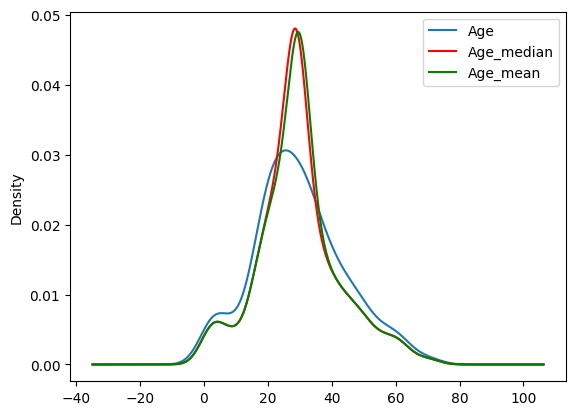

In [41]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Age'].plot(kind='kde',ax=ax)

# Variable distribution with median imputation
X_train['Age_median'].plot(kind='kde',ax=ax,color='red')

# Variable distribution with mean imputation
X_train['Age_mean'].plot(kind='kde',ax=ax,color='green')

lines , labels = ax.get_legend_handles_labels()
ax.legend(lines, labels , loc='best')

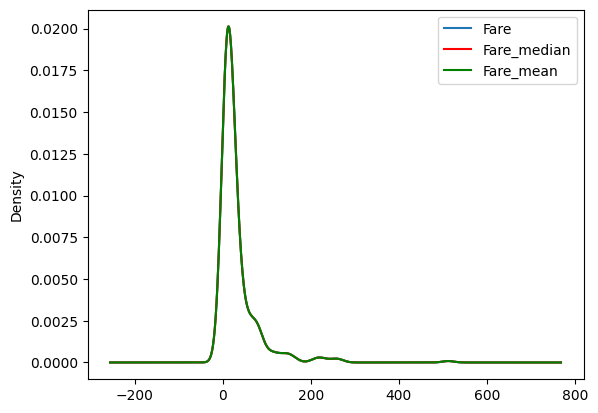

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Fare'].plot(kind='kde',ax=ax)

# Variable distribution with median imputation
X_train['Fare_median'].plot(kind='kde',ax=ax,color='red')

# Variable distribution with mean imputation
X_train['Fare_mean'].plot(kind='kde',ax=ax,color='green')

lines , labels = ax.get_legend_handles_labels()
ax.legend(lines, labels , loc='best')

In [43]:
X_train.cov() # To check the covariance ,i.e,relationship between columns

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,71.512440,-6.498901,204.349513,204.349513,71.512440,71.512440
Fare,71.512440,2368.246832,16.847264,58.986531,56.626587,2368.246832,2368.246832
Family,-6.498901,16.847264,2.735252,-5.112563,-5.146106,16.847264,16.847264
Age_median,204.349513,58.986531,-5.112563,161.989566,161.812625,58.986531,58.986531
Age_mean,204.349513,56.626587,-5.146106,161.812625,161.812625,56.626587,56.626587
Fare_median,71.512440,2368.246832,16.847264,58.986531,56.626587,2368.246832,2368.246832
Fare_mean,71.512440,2368.246832,16.847264,58.986531,56.626587,2368.246832,2368.246832


In [44]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.095814,-0.299113,1.000000,1.000000,0.095814,0.095814
Fare,0.095814,1.000000,0.209323,0.095235,0.091475,1.000000,1.000000
Family,-0.299113,0.209323,1.000000,-0.242883,-0.244610,0.209323,0.209323
Age_median,1.000000,0.095235,-0.242883,1.000000,0.999454,0.095235,0.095235
Age_mean,1.000000,0.091475,-0.244610,0.999454,1.000000,0.091475,0.091475
Fare_median,0.095814,1.000000,0.209323,0.095235,0.091475,1.000000,1.000000
Fare_mean,0.095814,1.000000,0.209323,0.095235,0.091475,1.000000,1.000000


<Axes: >

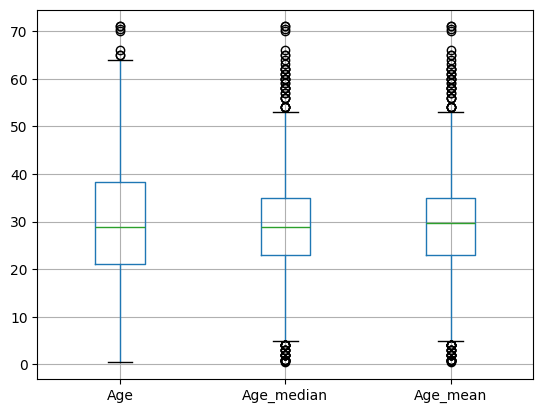

In [45]:
X_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

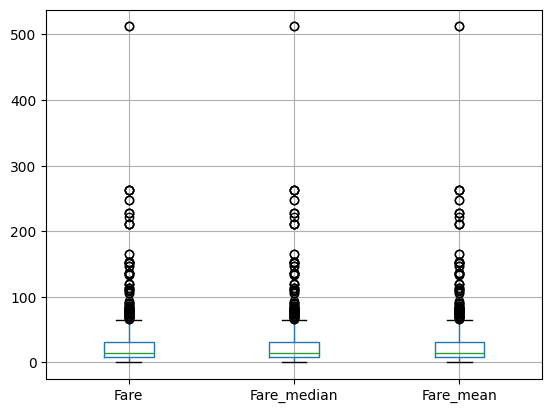

In [46]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

End result is that we can use Mean_Median Imputation for Fare but not for Age because there are many Red Flags

### Imputation using Sci-Kit Learn - (returns Numpy Arrays)

In [47]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [49]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [50]:
trf = ColumnTransformer([
    ("imputer1",imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
], remainder = 'passthrough')

In [51]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [52]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [53]:
trf.named_transformers_['imputer2'].statistics_

array([32.28905604])

In [54]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

# Arbitrary Value Imputation

### Using Pandas

df = pd.read_csv('titanic.csv',usecols=['Age','Fare','SibSp','Parch','Survived'])
df['Family'] = df['SibSp'] + df['Parch']
df.drop(columns=['SibSp','Parch'],inplace=True)
X = df.drop(columns='Survived')
y = df['Survived']
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [63]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [84]:
X_train.sample(5)

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
638,41.0,39.6875,5,41.0,41.0,39.6875,39.6875
738,NaN,7.8958,0,99.0,-1.0,7.8958,7.8958
361,29.0,27.7208,1,29.0,29.0,27.7208,27.7208
184,4.0,22.0250,2,4.0,4.0,22.0250,22.0250
252,62.0,26.5500,0,62.0,62.0,26.5500,26.5500


In [85]:
print('Original Age variable variance : ',X_train['Age'].var())
print('Age variance after 99 Imputation : ',X_train['Age_99'].var())
print('Age variance after -1 Imputation : ',X_train['Age_minus1'].var())

print('Original Fare variable variance : ',X_train['Fare'].var())
print('Fare variance after 99 Imputation : ',X_train['Fare_999'].var())
print('Fare variance after -1 Imputation : ',X_train['Fare_minus1'].var())

Original Age variable variance :  204.3495133904614
Age variance after 99 Imputation :  951.7275570187172
Age variance after -1 Imputation :  318.0896202624484
Original Fare variable variance :  2368.2468324201386
Fare variance after 99 Imputation :  2368.2468324201386
Fare variance after -1 Imputation :  2368.2468324201386


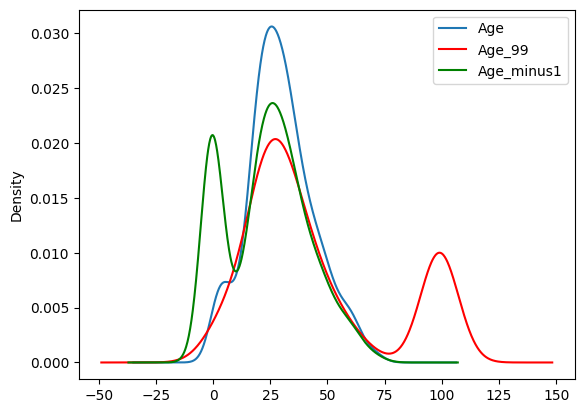

In [86]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Age'].plot(kind='kde',ax=ax)

# Variable distribution with median imputation
X_train['Age_99'].plot(kind='kde',ax=ax,color='red')

# Variable distribution with mean imputation
X_train['Age_minus1'].plot(kind='kde',ax=ax,color='green')

lines , labels = ax.get_legend_handles_labels()
ax.legend(lines, labels , loc='best')

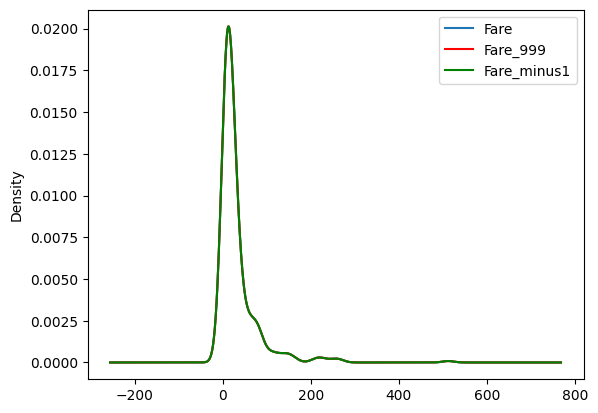

In [87]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Fare'].plot(kind='kde',ax=ax)

# Variable distribution with median imputation
X_train['Fare_999'].plot(kind='kde',ax=ax,color='red')

# Variable distribution with mean imputation
X_train['Fare_minus1'].plot(kind='kde',ax=ax,color='green')

lines , labels = ax.get_legend_handles_labels()
ax.legend(lines, labels , loc='best')

In [88]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,71.512440,-6.498901,204.349513,204.349513,71.512440,71.512440
Fare,71.512440,2368.246832,16.847264,-101.053412,126.761454,2368.246832,2368.246832
Family,-6.498901,16.847264,2.735252,-7.387287,-4.149246,16.847264,16.847264
Age_99,204.349513,-101.053412,-7.387287,951.727557,-189.535540,-101.053412,-101.053412
Age_minus1,204.349513,126.761454,-4.149246,-189.535540,318.089620,126.761454,126.761454
Fare_999,71.512440,2368.246832,16.847264,-101.053412,126.761454,2368.246832,2368.246832
Fare_minus1,71.512440,2368.246832,16.847264,-101.053412,126.761454,2368.246832,2368.246832


In [89]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.095814,-0.299113,1.000000,1.000000,0.095814,0.095814
Fare,0.095814,1.000000,0.209323,-0.067310,0.146049,1.000000,1.000000
Family,-0.299113,0.209323,1.000000,-0.144787,-0.140668,0.209323,0.209323
Age_99,1.000000,-0.067310,-0.144787,1.000000,-0.344476,-0.067310,-0.067310
Age_minus1,1.000000,0.146049,-0.140668,-0.344476,1.000000,0.146049,0.146049
Fare_999,0.095814,1.000000,0.209323,-0.067310,0.146049,1.000000,1.000000
Fare_minus1,0.095814,1.000000,0.209323,-0.067310,0.146049,1.000000,1.000000


### Using Sci-Kit Learn

In [90]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [91]:
imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

In [92]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


# Random Sample Imputation

In [132]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [133]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [134]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [135]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [136]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [137]:
# Random Imputation code

X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

# X_train['Age'].isnull().sum()).values = number of missing values

C:\Users\DELL\AppData\Local\Temp\ipykernel_21848\3980667792.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C:

In [138]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([39.  , 24.  , 40.  , 18.  , 17.  , 26.  , 16.  , 11.  , 34.  ,
       16.  , 47.  , 61.  , 17.  , 32.  , 41.  , 34.  , 33.  , 18.  ,
       14.  , 24.  ,  8.  , 38.  , 28.5 , 14.  , 29.  , 36.  , 29.  ,
       22.  , 27.  , 45.  , 32.  , 28.  , 28.  , 45.  ,  3.  , 28.  ,
       50.  , 17.  , 60.  , 21.  , 21.  , 59.  , 63.  , 19.  ,  5.  ,
       43.  , 52.  ,  9.  , 41.  , 32.  , 38.  , 30.  , 53.  , 42.  ,
       24.  , 56.  , 31.  , 25.  , 18.  , 36.  , 47.  , 62.  , 35.  ,
       34.  , 18.  , 32.  , 16.  , 17.  , 30.  , 62.  , 30.  , 51.  ,
       21.  , 20.  , 30.  , 33.  , 18.  , 24.  , 45.  , 22.  , 33.  ,
       20.  , 52.  , 33.  , 24.  , 22.  , 19.  , 21.  ,  9.  ,  0.83,
       16.  , 16.  ,  2.  ,  9.  , 39.  , 25.  , 56.  , 32.  , 50.  ,
       28.5 , 22.  , 54.  , 24.  , 40.  , 42.  , 57.  , 38.  , 12.  ,
       17.  , 27.  , 28.  , 20.  , 40.  , 16.  , 25.  , 46.  , 32.  ,
       36.  , 37.  , 36.  , 52.  , 33.  , 41.  , 37.  , 27.  , 29.  ,
       27.  , 24.  ,

In [139]:
X_train['Age'].isnull().sum()

np.int64(148)

In [102]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,57.0
493,71.0,49.5042,71.0
527,NaN,221.7792,38.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_21848\3157945262.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\DELL\AppData\Local\Temp\ipykernel_21848\3157945262.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['A

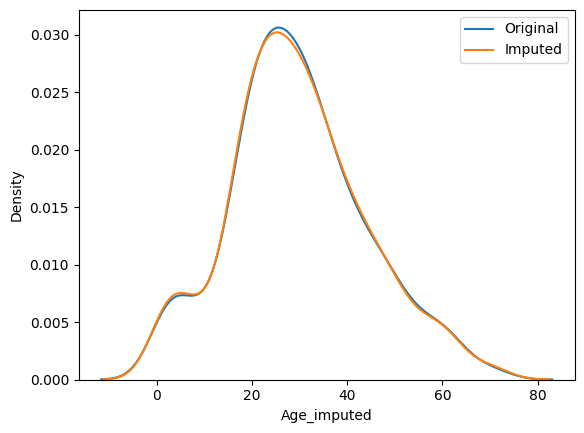

In [140]:
import seaborn as sns

sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [104]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  203.92309199576488


In [105]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,55.082846
Age,71.512440,204.349513,204.349513
Age_imputed,55.082846,204.349513,203.923092


<Axes: >

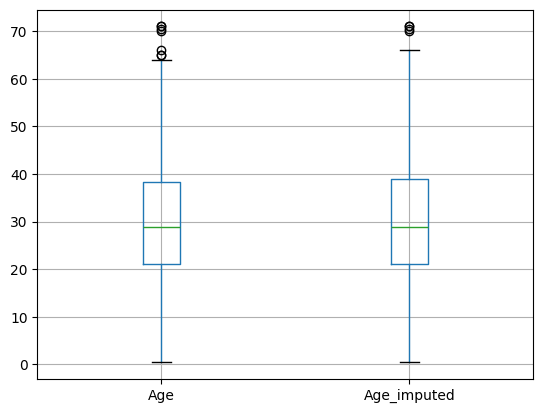

In [106]:
X_train[['Age', 'Age_imputed']].boxplot()

In [107]:
# To generate same random Age for a paricular input in production
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

NameError: name 'observation' is not defined

# Missing Indicator

In [150]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import MissingIndicator , SimpleImputer

In [165]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [166]:
X = df.drop(columns='Survived')
y = df['Survived']

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [167]:
si = SimpleImputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [168]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_trf , y_train)

y_pred = clf.predict(X_test_trf)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6145251396648045

In [169]:
mi = MissingIndicator()

mi.fit(X_train)

,missing_values,nan
,features,'missing-only'
,sparse,'auto'
,error_on_new,True


In [170]:
X_train_missing = mi.transform(X_train)
X_test_missing =  mi.transform(X_test)

X_train_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [172]:
X_train['Age_na'] = X_train_missing
X_test['Age_na'] = X_test_missing

In [173]:
X_train

,Age,Fare,Age_na
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [174]:
si = SimpleImputer()

X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [175]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_trf2,y_train)

y_pred = clf.predict(X_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.6312849162011173

#### Directly without using Missing Indicator class :--

In [176]:
si = SimpleImputer(add_indicator=True)

In [177]:
X_train = si.fit_transform(X_train)
X_test = si.transform(X_test)

In [178]:
clf.fit(X_train_trf2,y_train)

y_pred = clf.predict(X_test_trf2)

accuracy_score(y_pred,y_test)

0.6312849162011173